# Missing deposit data in gold before March 2026

**The question for the team.** The churn model reads the gold layer, which has 18 months of history (from April 2025). But **completed deposits and withdrawals only exist in gold from March 2026**. The deposit features, which are among the strongest churn signals, are therefore empty for most of the training history. The feature selection of the plan drops any feature with more than 40% empty values, so as things stand **the model would be trained without any deposit information**. This notebook shows the gap, its effect on the model and the options, so the team can decide.

Data: the local caches built from gold (`src/features/gold_cache.py`), brand 64. Nothing is read from S3.

In [1]:
import datetime as dt
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "eda" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src" / "features"))
import build_features as bf
import gold_cache

BRAND = 64
pd.set_option("display.width", 200)

## 1. Completed deposits per month

Players with at least one completed deposit, out of the players with a bet that month (`gld_player_payments_daily` against the betting activity). The red line is the first day the pipeline treats deposits as valid (`DEPOSITS_VALID_FROM`).

/tmp/ipykernel_455715/783353853.py:17: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  ax2.bar(x - pd.Timedelta(days=5), monthly["deposit_count"], width=10, label="completed deposits", color="#2a9d8f")
/tmp/ipykernel_455715/783353853.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  ax2.bar(x + pd.Timedelta(days=5), monthly["failed_deposit_count"], width=10, label="failed deposits", color="#e76f51")


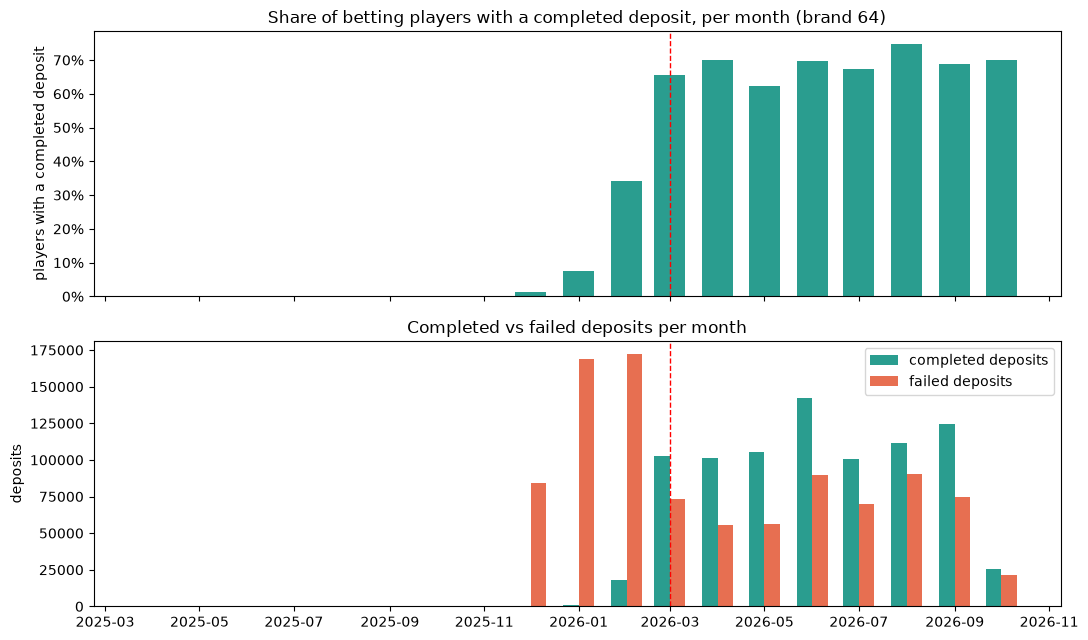

,players_betting,depositors,deposit_count,failed_deposit_count,withdraw_count,depositor_share
month,,,,,,
2025-04,"30,600",0,0,0,0,0.0%
2025-05,"35,603",0,0,0,0,0.0%
2025-06,"27,606",0,0,0,0,0.0%
2025-07,"19,444",0,0,0,0,0.0%
2025-08,"18,583",0,0,0,0,0.0%
2025-09,"19,331",0,0,0,0,0.0%
2025-10,"22,252",0,0,0,0,0.0%
2025-11,"17,981",0,0,0,0,0.0%
2025-12,"14,708",180,213,"84,249",7,1.2%


In [2]:
act = gold_cache.read("activity", BRAND, columns="tenant_id, player_id, day")
pay = gold_cache.read("payments", BRAND, columns="tenant_id, player_id, day, deposit_count, failed_deposit_count, withdraw_count")
for frame in (act, pay):
    frame["month"] = pd.to_datetime(frame["day"]).dt.to_period("M")
monthly = pd.concat([
    act.groupby("month")["player_id"].nunique().rename("players_betting"),
    pay[pay["deposit_count"] > 0].groupby("month")["player_id"].nunique().rename("depositors"),
    pay.groupby("month")[["deposit_count", "failed_deposit_count", "withdraw_count"]].sum(),
], axis=1).fillna(0)
monthly["depositor_share"] = monthly["depositors"] / monthly["players_betting"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
x = monthly.index.to_timestamp()
ax1.bar(x, monthly["depositor_share"], width=20, color="#2a9d8f")
ax1.set_ylabel("players with a completed deposit"); ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax1.set_title("Share of betting players with a completed deposit, per month (brand 64)")
ax2.bar(x - pd.Timedelta(days=5), monthly["deposit_count"], width=10, label="completed deposits", color="#2a9d8f")
ax2.bar(x + pd.Timedelta(days=5), monthly["failed_deposit_count"], width=10, label="failed deposits", color="#e76f51")
ax2.set_ylabel("deposits"); ax2.legend(); ax2.set_title("Completed vs failed deposits per month")
for ax in (ax1, ax2):
    ax.axvline(pd.Timestamp(bf.DEPOSITS_VALID_FROM), color="red", linestyle="--", linewidth=1)
fig.tight_layout(); plt.show()
monthly.style.format({"players_betting": "{:,.0f}", "depositors": "{:,.0f}", "deposit_count": "{:,.0f}",
                      "failed_deposit_count": "{:,.0f}", "withdraw_count": "{:,.0f}", "depositor_share": "{:.1%}"})

**Reading.** From April to November 2025 no betting player has a completed deposit. In December 2025 and January 2026 a few appear, while the failed deposits are in the tens of thousands per month. February is a transition, and from March 2026 about 62% to 75% of the betting players deposit, with around 100,000 completed deposits per month. Players cannot have played for a year without depositing: this is a gap in the data, most likely payments that were not marked as completed before February 2026.

## 2. The same gap in every gold table with deposits

- `gld_player_signals_daily`: `deposits_eur_l30d`, `withdrawals_eur_l30d` (the 30-day windows the features read).
- `gld_player_financial_daily`: `deposits_eur_today` and `withdrawals_eur_today` are 0 on every row until May 2026; they only appear from June 2026, three months after the payments table.

The share of the population with any deposit in the 30 days up to each monthly cutoff, from the signal snapshots:

In [3]:
frame = pd.read_parquet(PROJECT_ROOT / f"data/02_intermediate/signal_frame_brand{BRAND}.parquet",
                        columns=["cutoff_date", "deposits_eur_l30d", "withdrawals_eur_l30d"])
in_signals = frame.groupby("cutoff_date").agg(
    players=("deposits_eur_l30d", "size"),
    with_deposits_30d=("deposits_eur_l30d", lambda s: (s > 0).mean()),
    with_withdrawals_30d=("withdrawals_eur_l30d", lambda s: (s > 0).mean()))
fin = gold_cache.read("financial", BRAND, columns="day, deposits_eur, withdrawals_eur")
fin["month"] = pd.to_datetime(fin["day"]).dt.to_period("M")
print("gld_player_financial_daily, brand 64: player-days with a deposit / a withdrawal, per month")
print(fin.groupby("month").agg(player_days=("day", "size"), with_deposit=("deposits_eur", lambda s: int((s > 0).sum())),
                               with_withdrawal=("withdrawals_eur", lambda s: int((s > 0).sum()))).to_string())
in_signals.style.format({"players": "{:,}", "with_deposits_30d": "{:.1%}", "with_withdrawals_30d": "{:.1%}"})

gld_player_financial_daily, brand 64: player-days with a deposit / a withdrawal, per month
         player_days  with_deposit  with_withdrawal
month                                              
2025-04       128889             0                0
2025-05       145819             0                0
2025-06       120358             0                0
2025-07       110117             0                0
2025-08       110872             0                0
2025-09       112355             0                0
2025-10       120007             0                0
2025-11        91823             0                0
2025-12        56861             0                0
2026-01        61711             0                0
2026-02        68264             0                0
2026-03        76043             0                0
2026-04        71946             0                0
2026-05        76943             0                0
2026-06        64225         25646             4953
2026-07        70027     

,players,with_deposits_30d,with_withdrawals_30d
cutoff_date,,,
2025-06-01,"34,106",0.0%,0.0%
2025-07-01,"27,427",0.0%,0.0%
2025-08-01,"19,120",0.0%,0.0%
2025-09-01,"18,433",0.0%,0.0%
2025-10-01,"19,279",0.0%,0.0%
2025-11-01,"22,163",0.0%,0.0%
2025-12-01,"17,727",0.0%,0.0%
2026-01-01,"14,569",1.4%,0.0%
2026-02-01,"11,878",7.8%,0.2%


## 3. What the pipeline does with it

Writing 0 deposits for a player before March 2026 would be wrong: the player probably deposited, gold just does not have it. So the pipeline leaves a deposit feature **empty (unknown)** at any cutoff whose window starts before 2026-03-01. With the 12 monthly training cutoffs of a run as of 2026-10-06 (2025-09-01 to 2026-08-01), this is what each deposit feature looks like:

/tmp/ipykernel_455715/2333614977.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  players = pd.Series({c: act[(pd.to_datetime(act["day"]) > pd.Timestamp(c) - pd.Timedelta(days=bf.LOOKBACK_DAYS))
/tmp/ipykernel_455715/2333614977.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  players = pd.Series({c: act[(pd.to_datetime(act["day"]) > pd.Timestamp(c) - pd.Timedelta(days=bf.LOOKBACK_DAYS))
/tmp/ipykernel_455715/2333614977.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  players =

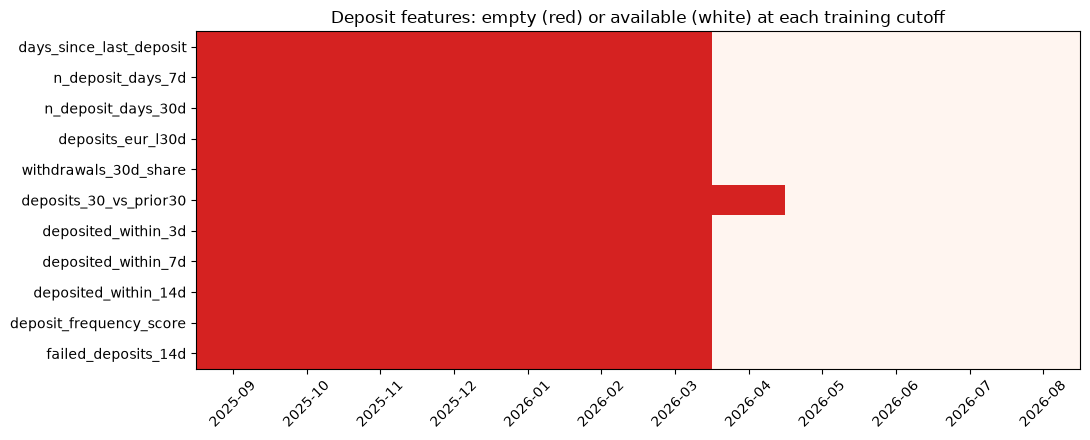

training rows: 180,122 over 12 cutoffs; rows at cutoffs with deposit data (from 2026-04-01): 63,451


,share of training rows empty
days_since_last_deposit,65%
n_deposit_days_7d,65%
n_deposit_days_30d,65%
deposits_eur_l30d,65%
withdrawals_30d_share,65%
deposits_30_vs_prior30,72%
deposited_within_3d,65%
deposited_within_7d,65%
deposited_within_14d,65%
deposit_frequency_score,65%


In [4]:
cutoffs = [d.date() for d in pd.date_range("2025-09-01", "2026-08-01", freq="MS")]
players = pd.Series({c: act[(pd.to_datetime(act["day"]) > pd.Timestamp(c) - pd.Timedelta(days=bf.LOOKBACK_DAYS))
                            & (pd.to_datetime(act["day"]) <= pd.Timestamp(c))][["tenant_id", "player_id"]].drop_duplicates().shape[0]
                     for c in cutoffs})
deposit_features = [f for f in bf.FEATURES if f in bf.DEPOSIT_WINDOWS]
empty = pd.DataFrame({f: [c - dt.timedelta(days=bf.DEPOSIT_WINDOWS[f] - 1) < bf.DEPOSITS_VALID_FROM for c in cutoffs]
                      for f in deposit_features}, index=cutoffs)
share_empty = (empty.mul(players, axis=0).sum() / players.sum()).rename("share of training rows empty")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.imshow(empty.T.to_numpy(), cmap="Reds", aspect="auto", vmin=0, vmax=1.4)
ax.set_xticks(range(len(cutoffs)), [str(c)[:7] for c in cutoffs], rotation=45)
ax.set_yticks(range(len(deposit_features)), deposit_features)
ax.set_title("Deposit features: empty (red) or available (white) at each training cutoff")
fig.tight_layout(); plt.show()
print(f"training rows: {players.sum():,} over {len(cutoffs)} cutoffs; "
      f"rows at cutoffs with deposit data (from 2026-04-01): {players[[c for c in cutoffs if c >= dt.date(2026, 4, 1)]].sum():,}")
share_empty.to_frame().style.format("{:.0%}")

## 4. Consequence: the feature selection removes every deposit feature

Step 1 of the plan's feature selection drops a feature with more than 40% empty values. Every deposit feature is empty in more than half of the training rows, so all of them are dropped, and **the model learns nothing about deposits**.

In [5]:
dropped = share_empty[share_empty > 0.40]
print(f"{len(dropped)} of {len(deposit_features)} deposit features are over the 40% limit and would be dropped:")
print(", ".join(dropped.index))

11 of 11 deposit features are over the 40% limit and would be dropped:
days_since_last_deposit, n_deposit_days_7d, n_deposit_days_30d, deposits_eur_l30d, withdrawals_30d_share, deposits_30_vs_prior30, deposited_within_3d, deposited_within_7d, deposited_within_14d, deposit_frequency_score, failed_deposits_14d


## 5. Why it matters: deposits are among the strongest signals

Single-signal results from the signal explorer (T4, `docs/churn_signals_v0.md`), measured on the only two training cutoffs with deposit data (2026-04-01 and 2026-05-01), next to the strongest signals that do not depend on deposits:

In [6]:
t = pd.read_csv(PROJECT_ROOT / f"data/03_output/signals/brand{BRAND}/signal_summary.csv")
t["separation"] = (t["auc"] - 0.5).abs()
t["uses_deposits"] = t["signal"].isin(bf.DEPOSIT_WINDOWS)
show = t[t["decision"] != "REJECTED"].sort_values("separation", ascending=False).head(12)
show[["signal", "uses_deposits", "auc", "lift", "hazard_ratio", "cutoffs_checked"]].style.format(
    {"auc": "{:.3f}", "lift": "{:.2f}", "hazard_ratio": "{:.2f}"}).hide(axis="index")

signal,uses_deposits,auc,lift,hazard_ratio,cutoffs_checked
engagement_score,False,0.181,0.10,0.46,12
n_deposit_days_30d,True,0.211,0.06,0.40,2
days_since_last_deposit,True,0.774,9.75,2.23,2
tenure_days,False,0.232,0.29,0.49,12
days_since_last_bet,False,0.758,5.10,1.73,12
deposited_within_14d,True,0.286,0.28,0.28,2
games_breadth_30d,False,0.287,0.31,0.62,12
n_deposit_days_7d,True,0.300,0.15,0.48,2
deposited_within_7d,True,0.309,0.20,0.27,2
deposit_frequency_score,True,0.320,0.25,0.56,2


**Reading.** 6 of the 12 strongest signals are deposit signals: days with a deposit in the last 30 days (AUC 0.211), days since the last deposit (0.774), a deposit in the last 14 days (0.286). They match the plan's expectation (the deposit and win/loss hypotheses "are expected to be strong"). But they rest on two cutoffs only, so their stability over time cannot be checked yet.

## 6. Options

| Option | What it means | For | Against |
|---|---|---|---|
| **A. Backfill (data team)** | Fix the gold payments history before March 2026 (completed status) | The right fix: every option below becomes unnecessary; 12 months with deposits | Depends on the data team; time unknown |
| **B. Keep 12 months, no deposit features** | Today's behaviour: the selection drops them | Simple; long history, every season; stable backtest | The model ignores one of the strongest signal families |
| **C. Keep 12 months, keep deposit features empty where unknown** | Lift the 40% rule for the deposit features; LightGBM handles empty values | Uses the deposits where they exist | "Empty" also means "before March 2026", so the model can confuse the data gap with a period effect; Cox PH cannot use empty values |
| **D. Train only on cutoffs with deposit data** | Training cutoffs from 2026-04-01 (5 months with a 60-day label as of 2026-10-06) | Every feature complete and consistent | 5 months instead of 12, one season only; the 12-cutoff backtest of the plan is not possible yet |
| **E. Two models, compared** | Train B and D (or C) and compare them on the same test month | A decision based on numbers, not on opinion | More work; the comparison only covers the recent months |

**My recommendation:** ask for **A** now; meanwhile run **E** (B against D on the same test month) and keep the better one, with B as the default because it is the most stable.

## Questions for the team

1. **Is the gap known?** Why are completed deposits and withdrawals missing from gold before March 2026 (and why are there so many failed ones in December to February)? Can the history be backfilled, and when?
2. **`gld_player_financial_daily`**: `deposits_eur_today` and `withdrawals_eur_today` are 0 until May 2026 and only appear from June 2026, three months after `gld_player_payments_daily`. Why do the two tables start at different dates?
3. **Until a backfill exists**, which option do we take: B (no deposits), C (deposits where known) or D (recent months only)?